<a href="https://colab.research.google.com/github/SriSharanya-617/deeplearning/blob/main/RNN_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive/', force_remount=True)

# Path to the dataset (update if needed)
path = '/content/drive/My Drive/IMDB_Dataset.csv'

# Importing the dataset
data= pd.read_csv(path)

Mounted at /content/drive/


In [17]:
"""
Task 1: Understanding the Business Problem
Sentiment Analysis using RNN
"""

# -----------------------------------------
# 1. Why Text Reviews are Sequential Data
# -----------------------------------------

# Example reviews
review1 = "This product is good"
review2 = "This product is not good"

print("Review 1:", review1)
print("Review 2:", review2)

"""
Explanation:
- Text data is sequential because words appear in a specific order.
- Changing the order changes the meaning.
- Example:
    "good product" != "product good" (less meaningful)
    "not good" completely changes sentiment

Hence, word order matters → sequence is important.
"""

# -----------------------------------------
# 2. Why Traditional ML Models Struggle
# -----------------------------------------

from sklearn.feature_extraction.text import CountVectorizer

reviews = [
    "This product is good",
    "This product is not good"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(reviews)

print("\nFeature Names:", vectorizer.get_feature_names_out())
print("Vector Representation:\n", X.toarray())

"""
Explanation:
- Traditional ML (like Naive Bayes, Logistic Regression)
  uses Bag-of-Words (BoW)

- Problem:
    - It ignores word order
    - "good" and "not good" look similar
    - No understanding of context

Thus, traditional models fail to capture:
    - sequence
    - context
    - meaning
"""

# -----------------------------------------
# 3. Why RNN is Suitable
# -----------------------------------------

"""
RNN (Recurrent Neural Network) is designed for sequential data.

Key advantages:
1. Sequential Memory:
   - RNN processes one word at a time
   - Remembers previous words using hidden state

2. Context Understanding:
   - "not good" → RNN understands 'not' affects 'good'

3. Order Preservation:
   - Words are processed in order

Example flow:
Input: "This product is not good"

Step-by-step:
This → product → is → not → good
        ↓ memory flows through sequence

RNN captures:
- dependency between words
- context of sentence
- overall sentiment

Hence, RNN is suitable for sentiment analysis.
"""

print("\nConclusion:")
print("RNN is ideal because it captures sequence, context, and memory in text data.")

Review 1: This product is good
Review 2: This product is not good

Feature Names: ['good' 'is' 'not' 'product' 'this']
Vector Representation:
 [[1 1 0 1 1]
 [1 1 1 1 1]]

Conclusion:
RNN is ideal because it captures sequence, context, and memory in text data.


In [18]:
# Import Libraries
import pandas as pd

# Load Dataset (already mounted in your code)
path = '/content/drive/My Drive/IMDB_Dataset.csv'
data = pd.read_csv(path)

# -----------------------------------------
# 1. Check Dataset Size
# -----------------------------------------
print("Dataset Shape:", data.shape)

# -----------------------------------------
# 2. Display Sample Data
# -----------------------------------------
print("\nFirst 5 Rows:")
print(data.head())

# -----------------------------------------
# 3. Count Positive vs Negative Reviews
# -----------------------------------------
print("\nSentiment Count:")
print(data['sentiment'].value_counts())

# -----------------------------------------
# 4. Display Sample Reviews
# -----------------------------------------
print("\nSample Reviews:")
for i in range(5):
    print(f"\nReview {i+1}:")
    print(data['review'][i])

# -----------------------------------------
# 5. Calculate Average Review Length
# -----------------------------------------
data['review_length'] = data['review'].apply(lambda x: len(x.split()))

print("\nAverage Review Length:", data['review_length'].mean())

# -----------------------------------------
# 6. Check if Dataset is Balanced
# -----------------------------------------
print("\nClass Distribution (%):")
print((data['sentiment'].value_counts() / len(data)) * 100)

# -----------------------------------------
# 7. Review Length Statistics
# -----------------------------------------
print("\nReview Length Stats:")
print(data['review_length'].describe())

Dataset Shape: (50000, 2)

First 5 Rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Sentiment Count:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Reviews:

Review 1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of

In [19]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
def clean_text(text):

    text = text.lower()   # lowercase

    text = re.sub("<.*?>", "", text)   # remove HTML tags

    text = re.sub("[^a-zA-Z]", " ", text)   # remove punctuation

    words = text.split()   # tokenize

    words = [w for w in words if w not in stop_words]   # remove stopwords

    return words

In [22]:
import pandas as pd # Import pandas

data = pd.read_csv(path) # Re-load data to ensure it's defined

data["processed"] = data["review"].apply(clean_text)

data.head()
print(data["review"][0])
print(data["processed"][0])

data["processed_text"] = data["processed"].apply(lambda x: " ".join(x))
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(data["processed_text"])
sequences = tokenizer.texts_to_sequences(data["processed_text"])

print(sequences[0])
word_index = tokenizer.word_index

print(list(word_index.items())[:10])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [23]:
# -----------------------------------------
# Find Maximum Review Length
# -----------------------------------------
max_length = max(len(seq) for seq in sequences)
print("Maximum Review Length:", max_length)

# -----------------------------------------
# Apply Padding
# -----------------------------------------
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='pre')

# -----------------------------------------
# Compare Before and After Padding
# -----------------------------------------
print("\nBefore Padding:")
print(sequences[0])

print("\nAfter Padding:")
print(padded_sequences[0])

Maximum Review Length: 910

Before Padding:
[3, 1897, 916, 55, 2915, 275, 3029, 98, 487, 464, 19, 54, 3074, 2915, 49, 434, 153, 98, 520, 51, 1583, 38, 2170, 38, 2428, 1319, 254, 434, 3639, 239, 240, 520, 311, 2915, 241, 2401, 897, 2542, 1263, 395, 4494, 2295, 1047, 2742, 267, 183, 4705, 2743, 395, 225, 31, 4847, 2284, 208, 34, 116, 131, 8, 48, 167, 1179, 38, 549, 90, 154, 161, 2851, 687, 80, 1156, 3979, 2330, 1078, 687, 1284, 687, 733, 2915, 805, 82, 19, 275, 42, 104, 3074, 1466, 2078, 48, 1429, 177, 1268, 1120, 2915, 88, 183, 1876, 1973, 434, 434, 4817, 2812, 371, 500, 15, 131, 12, 511, 566, 522, 1047, 549, 439, 759, 1859, 1047, 424, 55, 2915, 94, 304, 3657, 3142, 664, 1444, 15, 1065, 3915, 356]

After Padding:
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0

In [24]:
# -----------------------------------------
# Import Libraries
# -----------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# -----------------------------------------
# Define Parameters
# -----------------------------------------
vocab_size = 5000        # same as tokenizer
embedding_dim = 32
input_length = padded_sequences.shape[1]

# -----------------------------------------
# Build Model
# -----------------------------------------
model = Sequential()

# 1. Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length))

# 2. Simple RNN Layer
model.add(SimpleRNN(64, activation='tanh'))

# 3. Dense Output Layer
model.add(Dense(1, activation='sigmoid'))

# -----------------------------------------
# Compile Model
# -----------------------------------------
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# -----------------------------------------
# Model Summary
# -----------------------------------------
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 200s 311ms/step - accuracy: 0.7103 - loss: 0.5373 - val_accuracy: 0.6587 - val_loss: 0.6064
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 295ms/step - accuracy: 0.7551 - loss: 0.4995 - val_accuracy: 0.8250 - val_loss: 0.4009
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 215s 317ms/step - accuracy: 0.8496 - loss: 0.3615 - val_accuracy: 0.8459 - val_loss: 0.3618
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 198s 317ms/step - accuracy: 0.8668 - loss: 0.3299 - val_accuracy: 0.8499 - val_loss: 0.3573
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 187s 299ms/step - accuracy: 0.8809 - loss: 0.2960 - val_accuracy: 0.8474 - val_loss: 0.3559


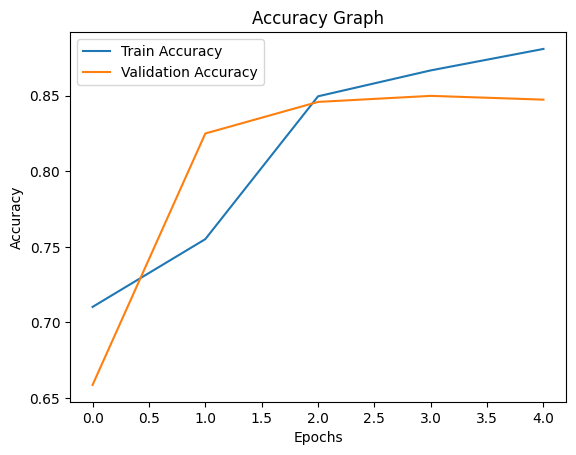

In [25]:
# -----------------------------------------
# Import Libraries
# -----------------------------------------
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# -----------------------------------------
# Convert labels to numeric
# -----------------------------------------
y = data['sentiment'].map({'positive':1, 'negative':0})

# -----------------------------------------
# Train-Test Split
# -----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, y, test_size=0.2, random_state=42
)

# -----------------------------------------
# Train Model
# -----------------------------------------
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# -----------------------------------------
# Plot Training Accuracy
# -----------------------------------------
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# -----------------------------------------
# Import Libraries
# -----------------------------------------
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------------------
# Predictions
# -----------------------------------------
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# -----------------------------------------
# Accuracy
# -----------------------------------------
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# -----------------------------------------
# Confusion Matrix
# -----------------------------------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# -----------------------------------------
# Precision, Recall, F1-score
# -----------------------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))